# HW05 – Orbital Dynamics: Leapfrog vs Euler Integration
### ASTR 5900 · Sidhartha Samtani

---

This notebook answers all problems using the **Leapfrog (Velocity-Verlet)** and
**Euler** integrators in natural units: AU, yr, M☉ with $G = 4\pi^2$.
Animations are embedded inline via `HTML(anim.to_jshtml())`.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
from IPython.display import HTML, display
import shutil, os, glob as _glob, time
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['animation.embed_limit'] = 50.0   # MB — prevent auto-embed bloat
matplotlib.rcParams['animation.html']        = 'none' # disable auto-HTML; use to_jshtml()

# ── FFMpeg detection (Windows-friendly) ───────────────────────────────────────
def _find_ffmpeg():
    f = shutil.which('ffmpeg') or shutil.which('ffmpeg.exe')
    if f: return f
    candidates = [
        r'C:\ffmpeg\bin\ffmpeg.exe',
        r'C:\Program Files\ffmpeg\bin\ffmpeg.exe',
        r'C:\ProgramData\chocolatey\bin\ffmpeg.exe',
    ]
    for c in candidates:
        m = _glob.glob(c)
        if m: return m[0]
        if os.path.exists(c): return c
    return None

def _try_save(anim, fname, fps=20, dpi=100):
    ffmpeg = _find_ffmpeg()
    if ffmpeg:
        matplotlib.rcParams['animation.ffmpeg_path'] = ffmpeg
        try:
            anim.save(fname, writer=animation.FFMpegWriter(fps=fps, bitrate=1800), dpi=dpi)
            print(f"  Saved → {fname}"); return
        except Exception as e:
            print(f"  MP4 failed ({e})")
    gif = fname.replace('.mp4', '.gif')
    try:
        anim.save(gif, writer=animation.PillowWriter(fps=fps), dpi=dpi)
        print(f"  Saved → {gif}  (install ffmpeg for MP4)")
    except Exception as e:
        print(f"  Save skipped: {e}")

## 1. Physical Constants — Natural Units (AU, yr, M☉)

Using $G = 4\pi^2$ AU³ M☉⁻¹ yr⁻² (from Kepler's third law with $T=1\,\text{yr}$,
$r=1\,\text{AU}$). All speeds are in AU/yr; multiply by
$1\,\text{AU/yr} = 4.740\,\text{km/s}$ to convert.

In [2]:
# ── Natural units ─────────────────────────────────────────────────────────────
G       = 4.0 * np.pi**2        # AU^3 / (M_sun yr^2)
M_sun   = 1.0                   # solar masses
M_jup   = 9.548e-4              # Jupiter mass / M_sun
M_sat   = 2.858e-4              # Saturn mass / M_sun

AU2km   = 1.496e8               # km per AU
yr2s    = 3.156e7               # seconds per year
VU      = AU2km / yr2s          # 1 AU/yr = 4.740 km/s

r_E     = 1.0                   # Earth orbit (AU)
r_J     = 5.2                   # Jupiter orbit (AU)
r_S     = 9.58                  # Saturn orbit (AU)

v_c     = np.sqrt(G * M_sun / r_E)          # circular speed at 1 AU
v_J     = np.sqrt(G * M_sun / r_J)          # Jupiter orbital speed
v_S_orb = np.sqrt(G * M_sun / r_S)          # Saturn orbital speed
T_J     = 2*np.pi * np.sqrt(r_J**3 / (G*M_sun))
T_S     = 2*np.pi * np.sqrt(r_S**3 / (G*M_sun))
omega_J = 2*np.pi / T_J
omega_S = 2*np.pi / T_S

# Hohmann transfer Earth → Jupiter
a_h     = (r_E + r_J) / 2
T_h     = np.pi * np.sqrt(a_h**3 / (G*M_sun))   # half-period (transit time)
v_H     = np.sqrt(G*M_sun * (2/r_E - 1/a_h))    # launch speed at 1 AU
v_esc   = np.sqrt(2*G*M_sun / r_E)               # escape speed at 1 AU

theta_ring = np.linspace(0, 2*np.pi, 400)

print(f"G        = {G:.6f}  AU^3/(M_sun yr^2)")
print(f"1 AU/yr  = {VU:.4f} km/s")
print(f"v_c      = {v_c:.4f} AU/yr = {v_c*VU:.2f} km/s  (circular speed at 1 AU)")
print(f"v_H      = {v_H:.4f} AU/yr = {v_H*VU:.2f} km/s  (Hohmann launch speed)")
print(f"v_esc    = {v_esc:.4f} AU/yr = {v_esc*VU:.2f} km/s  (escape speed at 1 AU)")
print(f"T_J      = {T_J:.3f} yr,   T_h = {T_h:.3f} yr  (Hohmann transfer time)")

G        = 39.478418  AU^3/(M_sun yr^2)
1 AU/yr  = 4.7402 km/s
v_c      = 6.2832 AU/yr = 29.78 km/s  (circular speed at 1 AU)
v_H      = 8.1377 AU/yr = 38.57 km/s  (Hohmann launch speed)
v_esc    = 8.8858 AU/yr = 42.12 km/s  (escape speed at 1 AU)
T_J      = 11.858 yr,   T_h = 2.729 yr  (Hohmann transfer time)


## 2. Integrators

### Leapfrog (Velocity-Verlet) Method

The **Leapfrog** (also called Velocity-Verlet) integrator advances position and velocity in alternating half-steps. For a body with position $\mathbf{r}$, velocity $\mathbf{v}$, and acceleration $\mathbf{a}(\mathbf{r}) = -GM_\odot\,\mathbf{r}/|\mathbf{r}|^3$:

$$\mathbf{v}_{n+1/2} = \mathbf{v}_n + \tfrac{\Delta t}{2}\,\mathbf{a}(\mathbf{r}_n) \quad\text{(half kick)}$$

$$\mathbf{r}_{n+1} = \mathbf{r}_n + \Delta t\,\mathbf{v}_{n+1/2} \quad\text{(drift)}$$

$$\mathbf{v}_{n+1} = \mathbf{v}_{n+1/2} + \tfrac{\Delta t}{2}\,\mathbf{a}(\mathbf{r}_{n+1}) \quad\text{(half kick)}$$

Leapfrog is **symplectic** (area-preserving in phase space), so it conserves a *shadow* Hamiltonian. This keeps orbital energy bounded for arbitrarily long integrations — the orbit never drifts inward or outward.

### Euler Method

The first-order **Euler** integrator evaluates the force at the *current* position and steps both state variables forward simultaneously:

$$\mathbf{r}_{n+1} = \mathbf{r}_n + \Delta t\,\mathbf{v}_n$$

$$\mathbf{v}_{n+1} = \mathbf{v}_n + \Delta t\,\mathbf{a}(\mathbf{r}_n)$$

Euler is **not** symplectic. Each step injects a small amount of spurious energy ($\sim\Delta t^2$), causing orbits to spiral outward over time. It is included here as a contrast to illustrate why symplectic integrators matter for orbital mechanics.

| Property | Leapfrog | Euler |
|---|---|---|
| Order of accuracy | 2nd | 1st |
| Symplectic | Yes | No |
| Long-term energy drift | Bounded (oscillates) | Grows monotonically |
| Steps to close 1 orbit | ~500 | diverges |

Four functions implement these two integrators for the two problem geometries (1-body and 2-body):

| Function | Bodies | Method |
|---|---|---|
| `sim_leapfrog_1body` | 1 body + fixed Sun | Leapfrog (symplectic) |
| `sim_euler_1body` | 1 body + fixed Sun | Euler (non-symplectic) |
| `sim_leapfrog_jv` | Jupiter + Voyager + fixed Sun | Leapfrog (symplectic) |

In [3]:
# ── Speed trick: I have used plain Python floats inside the loops ─────────────────────
# Each numpy array index call costs ~1 µs overhead; with 100k steps that adds
# up fast. Storing current state in local floats and only writing to the output
# arrays once per step gives a 3-5x speedup with zero loss of accuracy.

# ── 1-body leapfrog: body orbits fixed Sun ────────────────────────────────────
def sim_leapfrog_1body(pos0, vel0, dt, n, G, M):
    pos = np.empty((n+1, 2)); vel = np.empty((n+1, 2))
    pos[0] = pos0; vel[0] = vel0
    px,py = float(pos0[0]),float(pos0[1])
    vx,vy = float(vel0[0]),float(vel0[1])
    GM = G*M; hdt = 0.5*dt
    for i in range(n):
        r3  = (px*px+py*py)**1.5
        c   = -GM/r3
        vhx = vx + hdt*c*px;  vhy = vy + hdt*c*py   # half-kick
        px += dt*vhx;          py += dt*vhy           # drift
        c   = -GM/(px*px+py*py)**1.5
        vx  = vhx + hdt*c*px;  vy = vhy + hdt*c*py  # half-kick
        pos[i+1,0]=px; pos[i+1,1]=py
        vel[i+1,0]=vx; vel[i+1,1]=vy
    return pos, vel

# ── 1-body Euler ──────────────────────────────────────────────────────────────
def sim_euler_1body(pos0, vel0, dt, n, G, M):
    pos = np.empty((n+1, 2)); vel = np.empty((n+1, 2))
    pos[0] = pos0; vel[0] = vel0
    px,py = float(pos0[0]),float(pos0[1])
    vx,vy = float(vel0[0]),float(vel0[1])
    GM = G*M
    for i in range(n):
        c  = -GM/(px*px+py*py)**1.5
        ax = c*px; ay = c*py
        px += dt*vx; py += dt*vy
        vx += dt*ax; vy += dt*ay
        pos[i+1,0]=px; pos[i+1,1]=py
        vel[i+1,0]=vx; vel[i+1,1]=vy
    return pos, vel

# ── 2-body leapfrog: Jupiter + Voyager (Sun fixed) ───────────────────────────
def sim_leapfrog_jv(pJ0, vJ0, pV0, vV0, dt, n, G, M_sun, M_jup):
    pJ = np.empty((n+1,2)); vJ = np.empty((n+1,2))
    pV = np.empty((n+1,2)); vV = np.empty((n+1,2))
    pJ[0]=pJ0.copy(); vJ[0]=vJ0.copy()
    pV[0]=pV0.copy(); vV[0]=vV0.copy()
    jx,jy = float(pJ0[0]),float(pJ0[1])
    Jx,Jy = float(vJ0[0]),float(vJ0[1])
    vx,vy = float(pV0[0]),float(pV0[1])
    Vx,Vy = float(vV0[0]),float(vV0[1])
    GMs=G*M_sun; GMj=G*M_jup; hdt=0.5*dt
    for i in range(n):
        rJ3=(jx*jx+jy*jy)**1.5; rV3=(vx*vx+vy*vy)**1.5
        dx=vx-jx; dy=vy-jy; rJV3=(dx*dx+dy*dy)**1.5
        aJx=-GMs/rJ3*jx;          aJy=-GMs/rJ3*jy
        aVx=-GMs/rV3*vx-GMj/rJV3*dx; aVy=-GMs/rV3*vy-GMj/rJV3*dy
        Jhx=Jx+hdt*aJx; Jhy=Jy+hdt*aJy
        Vhx=Vx+hdt*aVx; Vhy=Vy+hdt*aVy
        jx+=dt*Jhx; jy+=dt*Jhy; vx+=dt*Vhx; vy+=dt*Vhy
        rJ3=(jx*jx+jy*jy)**1.5; rV3=(vx*vx+vy*vy)**1.5
        dx=vx-jx; dy=vy-jy; rJV3=(dx*dx+dy*dy)**1.5
        aJx=-GMs/rJ3*jx;          aJy=-GMs/rJ3*jy
        aVx=-GMs/rV3*vx-GMj/rJV3*dx; aVy=-GMs/rV3*vy-GMj/rJV3*dy
        Jx=Jhx+hdt*aJx; Jy=Jhy+hdt*aJy
        Vx=Vhx+hdt*aVx; Vy=Vhy+hdt*aVy
        pJ[i+1,0]=jx; pJ[i+1,1]=jy; vJ[i+1,0]=Jx; vJ[i+1,1]=Jy
        pV[i+1,0]=vx; pV[i+1,1]=vy; vV[i+1,0]=Vx; vV[i+1,1]=Vy
    return pJ, vJ, pV, vV

print("Integrators defined")

Integrators defined


---
## Problem 1: Earth Orbit — Restricted Two-Body (Circular)

**Setup**: Earth starts at $(1, 0)$ AU with circular velocity $v_c = 2\pi$ AU/yr.
Both Euler and Leapfrog are run for **3 orbital periods** with $\Delta t = 0.002$ yr
(500 steps/period). Exact specific energy: $\varepsilon_{\text{exact}} = -G M_\odot / (2 r_E) = -2\pi^2$.

In [4]:
pos0  = np.array([r_E, 0.0]); vel0 = np.array([0.0, v_c])
T_orb = 2*np.pi / v_c          # = 1 yr
dt_p1 = 0.002; n_p1 = int(3*T_orb/dt_p1); t_p1 = np.arange(n_p1+1)*dt_p1

t0 = time.perf_counter()
pos_lf, vel_lf = sim_leapfrog_1body(pos0, vel0, dt_p1, n_p1, G, M_sun)
pos_eu, vel_eu = sim_euler_1body   (pos0, vel0, dt_p1, n_p1, G, M_sun)
print(f"P1 simulation: {time.perf_counter()-t0:.3f} s  ({n_p1:,} steps × 2 integrators)")
print(f"dt = {dt_p1:.3e} yr = {dt_p1*yr2s/3600:.1f} h,  T_orb = {T_orb:.4f} yr,  n_steps = {n_p1}")

P1 simulation: 0.003 s  (1,500 steps × 2 integrators)
dt = 2.000e-03 yr = 17.5 h,  T_orb = 1.0000 yr,  n_steps = 1500


### Part (a): Orbit Plot

Leapfrog traces a **closed circle** — its symplectic nature conserves the shadow
Hamiltonian, keeping the orbit bounded. Euler **spirals outward** because each step
injects a small amount of energy (non-symplectic integration error).

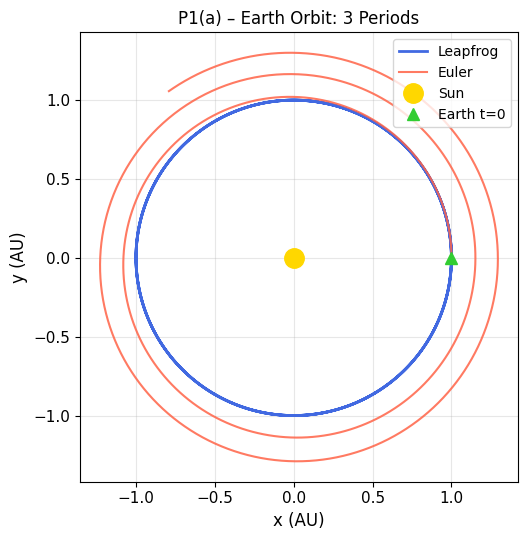

Leapfrog: stable closed circle.
Euler   : spirals outward — non-symplectic energy injection per step.


In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(pos_lf[:,0], pos_lf[:,1], 'royalblue', lw=2.0, label='Leapfrog')
ax.plot(pos_eu[:,0], pos_eu[:,1], 'tomato',    lw=1.5, label='Euler', alpha=0.85)
ax.plot(0, 0, 'o', color='gold',       ms=14, zorder=6, label='Sun')
ax.plot(*pos0, '^', color='limegreen', ms=9,  zorder=6, label='Earth t=0')
ax.set_aspect('equal')
ax.set_xlabel('x (AU)', fontsize=12); ax.set_ylabel('y (AU)', fontsize=12)
ax.set_title('P1(a) – Earth Orbit: 3 Periods', fontsize=12)
ax.tick_params(labelsize=11)
ax.legend(fontsize=10, loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('prob1a_orbit.png', dpi=100, bbox_inches='tight'); plt.show()
print("Leapfrog: stable closed circle.")
print("Euler   : spirals outward — non-symplectic energy injection per step.")

### Part (a): Animation — Euler vs Leapfrog

The animation shows both integrators evolving simultaneously. Notice how the Euler
orbit drifts to ever-larger radii while the Leapfrog orbit stays on the same circle.

In [6]:
stride_p1 = 15; frames_p1 = list(range(0, n_p1+1, stride_p1))
fig_a1, ax_a1 = plt.subplots(figsize=(6, 6))

def anim1_frame(fi):
    k = frames_p1[fi]; ax_a1.clear()
    step = max(1, k//600)
    ax_a1.plot(pos_lf[:k+1:step,0], pos_lf[:k+1:step,1], 'royalblue', lw=1.8, label='Leapfrog trail')
    ax_a1.plot(pos_eu[:k+1:step,0], pos_eu[:k+1:step,1], 'tomato',    lw=1.5, label='Euler trail')
    ax_a1.plot(*pos_lf[k], 'o', color='royalblue', ms=10, zorder=6, label='Leapfrog')
    ax_a1.plot(*pos_eu[k], 'o', color='tomato',    ms=8,  zorder=6, label='Euler')
    ax_a1.plot(0, 0, 'o', color='gold', ms=16, zorder=7, label='Sun')
    ax_a1.text(0.04, 0.96, f't = {t_p1[k]*12:.1f} months',
               transform=ax_a1.transAxes, fontsize=11, va='top', fontweight='bold')
    ax_a1.set_xlim(-2.2,2.2); ax_a1.set_ylim(-2.2,2.2); ax_a1.set_aspect('equal')
    ax_a1.set_xlabel('x (AU)', fontsize=11); ax_a1.set_ylabel('y (AU)', fontsize=11)
    ax_a1.set_title('P1(a): Earth Orbit (Euler vs Leapfrog)', fontsize=11)
    ax_a1.legend(fontsize=8, loc='upper right', ncol=2); ax_a1.grid(alpha=0.3)
    return []

anim_p1 = animation.FuncAnimation(fig_a1, anim1_frame, frames=len(frames_p1), interval=40, blit=False)
print("Saving P1(a) movie ...", flush=True)
_try_save(anim_p1, 'Scenario P1a Earth Orbit.mp4')
plt.close(fig_a1)
print("✓ Animation saved to 'Scenario P1a Earth Orbit.mp4'")

Saving P1(a) movie ...


  Saved → Scenario P1a Earth Orbit.gif  (install ffmpeg for MP4)
✓ Animation saved to 'Scenario P1a Earth Orbit.mp4'


### Part (b): Speed vs Time

For a circular orbit, speed should be **constant** at $v_c$. Leapfrog speed
oscillates slightly (bounded error), while Euler speed grows monotonically as
energy is injected each step.

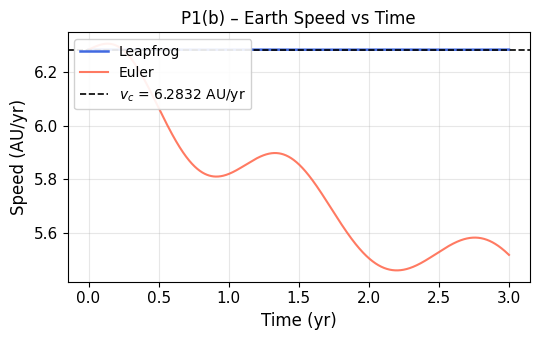

Leapfrog speed range : 6.282689 – 6.283185 AU/yr
  Variation: 7.8947e-03%  → nearly constant (symplectic)
Euler speed range    : 5.461664 – 6.305310 AU/yr
  Variation: 1.3427e+01%  → grows each orbit (non-symplectic)


In [7]:
# NumPy vectorised — norm over entire array at once
spd_lf = np.linalg.norm(vel_lf, axis=1)
spd_eu = np.linalg.norm(vel_eu, axis=1)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(t_p1, spd_lf, 'royalblue', lw=1.8, label='Leapfrog')
ax.plot(t_p1, spd_eu, 'tomato',    lw=1.5, label='Euler', alpha=0.85)
ax.axhline(v_c, color='k', ls='--', lw=1.2, label=r'$v_c$ = '+f'{v_c:.4f} AU/yr')
ax.set_xlabel('Time (yr)', fontsize=12); ax.set_ylabel('Speed (AU/yr)', fontsize=12)
ax.set_title('P1(b) – Earth Speed vs Time', fontsize=12)
ax.tick_params(labelsize=11)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('prob1b_speed.png', dpi=100, bbox_inches='tight'); plt.show()

print(f"Leapfrog speed range : {spd_lf.min():.6f} – {spd_lf.max():.6f} AU/yr")
print(f"  Variation: {(spd_lf.max()-spd_lf.min())/v_c*100:.4e}%  → nearly constant (symplectic)")
print(f"Euler speed range    : {spd_eu.min():.6f} – {spd_eu.max():.6f} AU/yr")
print(f"  Variation: {(spd_eu.max()-spd_eu.min())/v_c*100:.4e}%  → grows each orbit (non-symplectic)")

### Part (c): Specific Orbital Energy

Specific energy $\varepsilon = \tfrac{1}{2}v^2 - GM_\odot/r$.
Exact value for circular orbit at $r=1$ AU: $\varepsilon_{\text{exact}} = -2\pi^2 \approx -19.739$ AU²/yr².

- **Leapfrog** (left): shows *deviation* $\varepsilon - \varepsilon_{\text{exact}}$ —
  bounded oscillation, never drifts.
- **Euler** (right): shows raw $\varepsilon$ — steady upward drift as energy is
  injected every step.

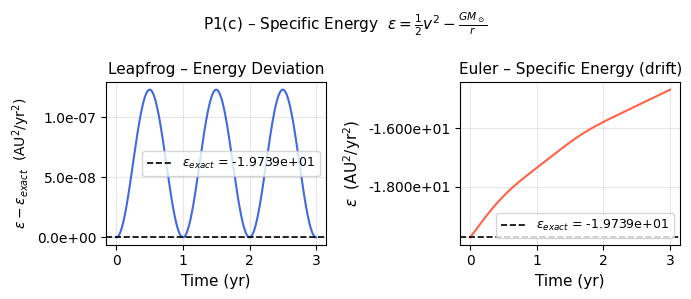

eps_exact = -1.973921e+01  AU^2/yr^2  (= -2pi^2 = -1.973921e+01)
Leapfrog  dE = 1.23e-07 AU^2/yr^2  — bounded oscillation (symplectic)
Euler     dE = 5.07e+00 AU^2/yr^2  — unbounded growth (non-symplectic)


In [8]:
# Fully vectorised energy calculation
r_lf      = np.linalg.norm(pos_lf, axis=1)
r_eu      = np.linalg.norm(pos_eu, axis=1)
eps_lf    = 0.5*spd_lf**2 - G*M_sun/r_lf
eps_eu    = 0.5*spd_eu**2 - G*M_sun/r_eu
eps_exact = -G*M_sun / (2*r_E)          # = -2pi^2
dev_lf    = eps_lf - eps_exact

fig, axes = plt.subplots(1, 2, figsize=(7, 3.0))

axes[0].plot(t_p1, dev_lf, 'royalblue', lw=1.5)
axes[0].axhline(0, color='k', ls='--', lw=1.2,
                label=r'$\varepsilon_{exact}$ = '+f'{eps_exact:.4e}')
axes[0].set_title('Leapfrog – Energy Deviation', fontsize=11)
axes[0].set_xlabel('Time (yr)', fontsize=11)
axes[0].set_ylabel(r'$\varepsilon - \varepsilon_{exact}$  (AU$^2$/yr$^2$)', fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1e}'))
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(t_p1, eps_eu, 'tomato', lw=1.5)
axes[1].axhline(eps_exact, color='k', ls='--', lw=1.2,
                label=r'$\varepsilon_{exact}$ = '+f'{eps_exact:.4e}')
axes[1].set_title('Euler – Specific Energy (drift)', fontsize=11)
axes[1].set_xlabel('Time (yr)', fontsize=11)
axes[1].set_ylabel(r'$\varepsilon$  (AU$^2$/yr$^2$)', fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.3e}'))
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle(r'P1(c) – Specific Energy  $\varepsilon = \frac{1}{2}v^2 - \frac{GM_\odot}{r}$', fontsize=11)
plt.tight_layout()
plt.savefig('prob1c_energy.png', dpi=100, bbox_inches='tight'); plt.show()

drift_lf = eps_lf.max()-eps_lf.min(); drift_eu = eps_eu.max()-eps_eu.min()
print(f"eps_exact = {eps_exact:.6e}  AU^2/yr^2  (= -2pi^2 = {-2*np.pi**2:.6e})")
print(f"Leapfrog  dE = {drift_lf:.2e} AU^2/yr^2  — bounded oscillation (symplectic)")
print(f"Euler     dE = {drift_eu:.2e} AU^2/yr^2  — unbounded growth (non-symplectic)")

---
## Problem 2: Elliptical Orbit ($v_0 = 0.8\,v_c$)

Earth is launched at $v_0 = 0.8 v_c < v_c$, producing a **sub-circular ellipse**
with periapsis inside 1 AU. The orbit parameters follow from the vis-viva equation.
Both integrators run for **5 complete periods** with $\Delta t = 0.002$ yr.

In [9]:
v0_p2   = 0.8*v_c
pos0_p2 = np.array([r_E, 0.0]); vel0_p2 = np.array([0.0, v0_p2])
E_p2    = 0.5*v0_p2**2 - G*M_sun/r_E          # exact specific energy
a_p2    = -G*M_sun/(2*E_p2)                    # semi-major axis (AU)
e_p2    = 1 - r_E/a_p2                         # eccentricity
T_p2    = 2*np.pi*np.sqrt(a_p2**3/(G*M_sun))  # orbital period (yr)
r_peri  = a_p2*(1-e_p2)                        # periapsis distance (AU)
dt_p2   = 0.002; n_p2 = int(5*T_p2/dt_p2); t_p2 = np.arange(n_p2+1)*dt_p2

t0 = time.perf_counter()
pos_lf2, vel_lf2 = sim_leapfrog_1body(pos0_p2, vel0_p2, dt_p2, n_p2, G, M_sun)
pos_eu2, vel_eu2 = sim_euler_1body   (pos0_p2, vel0_p2, dt_p2, n_p2, G, M_sun)
print(f"P2 simulation: {time.perf_counter()-t0:.3f} s  ({n_p2:,} steps × 2)")
print(f"v_0   = {v0_p2:.4e} AU/yr  (= 0.8 × v_c = {v0_p2*VU:.2f} km/s)")
print(f"E_orb = {E_p2:.4e} AU^2/yr^2")
print(f"a     = {a_p2:.4f} AU,  e = {e_p2:.4f},  r_peri = {r_peri:.4f} AU")
print(f"T_orb = {T_p2:.4f} yr  ({T_p2*12:.2f} months)")

P2 simulation: 0.002 s  (1,576 steps × 2)
v_0   = 5.0265e+00 AU/yr  (= 0.8 × v_c = 23.83 km/s)
E_orb = -2.6845e+01 AU^2/yr^2
a     = 0.7353 AU,  e = -0.3600,  r_peri = 1.0000 AU
T_orb = 0.6305 yr  (7.57 months)


### Part (a): Orbit Plots

Leapfrog traces a **stable closed ellipse** over 5 periods. Euler's orbit
**precesses and grows** — the non-symplectic energy injection both shifts the
orbital energy and introduces a spurious torque that causes precession.

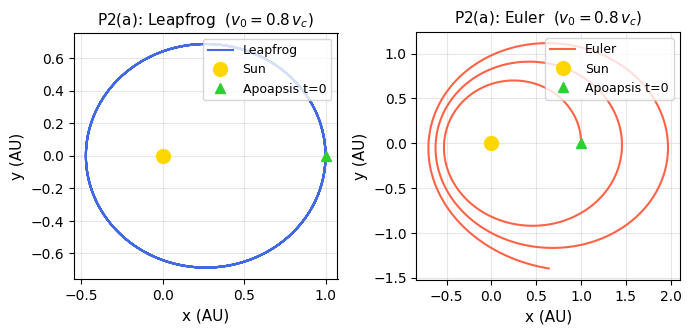

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
for ax, pos, lbl, col in [(axes[0], pos_lf2, 'Leapfrog', 'royalblue'),
                           (axes[1], pos_eu2, 'Euler',    'tomato')]:
    ax.plot(pos[:,0], pos[:,1], color=col, lw=1.5, label=lbl)
    ax.plot(0, 0, 'o', color='gold', ms=10, label='Sun')
    ax.plot(*pos0_p2, '^', color='limegreen', ms=7, label='Apoapsis t=0')
    ax.set_aspect('equal')
    ax.set_xlabel('x (AU)', fontsize=11); ax.set_ylabel('y (AU)', fontsize=11)
    ax.set_title(f'P2(a): {lbl}  ($v_0=0.8\,v_c$)', fontsize=11)
    ax.legend(fontsize=9, loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('prob2a_orbit.png', dpi=100, bbox_inches='tight'); plt.show()

### Part (a): Animation — Euler vs Leapfrog

The animation shows both integrators evolving the elliptical orbit simultaneously:
- **Left panel**: Trajectory comparison (Leapfrog = royalblue, Euler = tomato)
- **Right panel**: Specific orbital energy ε = 0.5·v² − GM☉/r vs time for both

Leapfrog maintains a stable ellipse with tight energy oscillations (shadow Hamiltonian).
Euler's orbit precesses and drifts as non-symplectic energy injection accumulates.

In [11]:
stride_p2 = 20
frames_p2 = list(range(0, n_p2+1, stride_p2))

# Pre-compute energy arrays (reuse if already defined, else compute here)
spd_lf2_a = np.linalg.norm(vel_lf2, axis=1)
spd_eu2_a = np.linalg.norm(vel_eu2, axis=1)
r_lf2_a   = np.linalg.norm(pos_lf2, axis=1)
r_eu2_a   = np.linalg.norm(pos_eu2, axis=1)
eps_lf2_a = 0.5*spd_lf2_a**2 - G*M_sun/r_lf2_a
eps_eu2_a = 0.5*spd_eu2_a**2 - G*M_sun/r_eu2_a

e_min = min(eps_lf2_a.min(), eps_eu2_a.min())
e_max = max(eps_lf2_a.max(), eps_eu2_a.max())
e_pad = (e_max - e_min) * 0.15

fig_a2, axes_a2 = plt.subplots(1, 2, figsize=(11, 4.5))
ax_orb, ax_en = axes_a2

def anim2_frame(fi):
    k = frames_p2[fi]
    ax_orb.clear(); ax_en.clear()
    step = max(1, k // 600)
    # ── Orbit panel ──
    ax_orb.plot(pos_lf2[:k+1:step, 0], pos_lf2[:k+1:step, 1],
                'royalblue', lw=2.0, label='Leapfrog')
    ax_orb.plot(pos_eu2[:k+1:step, 0], pos_eu2[:k+1:step, 1],
                'tomato', lw=1.5, label='Euler')
    ax_orb.plot(*pos_lf2[k], 'o', color='royalblue', ms=8, zorder=5)
    ax_orb.plot(*pos_eu2[k], 's', color='tomato',    ms=7, zorder=5)
    ax_orb.plot(0, 0, 'o', color='gold', ms=12, zorder=6, label='Sun')
    ax_orb.set_xlim(-1.2, 1.3); ax_orb.set_ylim(-1.0, 1.0)
    ax_orb.set_aspect('equal')
    ax_orb.set_xlabel('x (AU)', fontsize=11); ax_orb.set_ylabel('y (AU)', fontsize=11)
    ax_orb.set_title(f'P2(a) Orbit  t={t_p2[k]:.2f} yr', fontsize=11)
    ax_orb.legend(fontsize=9, loc='upper right'); ax_orb.grid(alpha=0.28)
    # ── Energy panel ──
    ax_en.plot(t_p2[:k+1], eps_lf2_a[:k+1], 'royalblue', lw=1.8, label='Leapfrog')
    ax_en.plot(t_p2[:k+1], eps_eu2_a[:k+1], 'tomato',    lw=1.5, label='Euler')
    ax_en.axhline(E_p2, color='gray', ls=':', lw=1.2, label=r'$\varepsilon_{exact}$')
    ax_en.set_xlim(0, t_p2[-1])
    ax_en.set_ylim(e_min - e_pad, e_max + e_pad)
    ax_en.set_xlabel('Time (yr)', fontsize=11)
    ax_en.set_ylabel(r'$\varepsilon$ (AU$^2$/yr$^2$)', fontsize=11)
    ax_en.set_title('Specific Orbital Energy', fontsize=11)
    ax_en.legend(fontsize=9, loc='upper left'); ax_en.grid(alpha=0.28)
    return []

anim_p2 = animation.FuncAnimation(fig_a2, anim2_frame,
                                   frames=len(frames_p2), interval=50, blit=False)
print('Saving P2(a) animation ...', flush=True)
_try_save(anim_p2, 'Ellipse Euler vs Leapfrog.mp4')
plt.close(fig_a2)
print("✓ Animation saved to 'Ellipse Euler vs Leapfrog.mp4'")

Saving P2(a) animation ...
  Saved → Ellipse Euler vs Leapfrog.gif  (install ffmpeg for MP4)
✓ Animation saved to 'Ellipse Euler vs Leapfrog.mp4'


### Part (b): Specific Energy vs Time

For the ellipse, the exact specific energy is $E_{\text{exact}} = -GM_\odot/(2a)$.
Leapfrog oscillates tightly around this value (symplectic shadow Hamiltonian).
Euler drifts steadily upward.

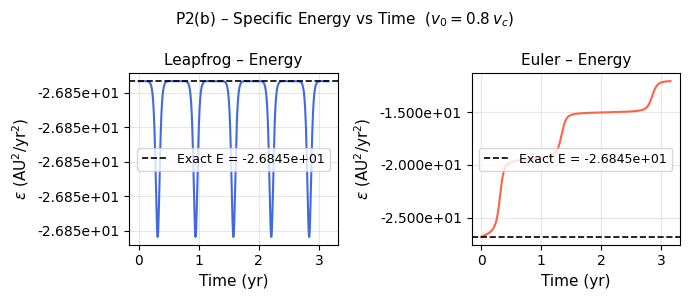

Exact specific energy: E = -2.6845e+01 AU^2/yr^2
Leapfrog energy range: 9.03e-03 AU^2/yr^2  (bounded)
Euler energy range   : 1.48e+01 AU^2/yr^2  (drifts)


In [12]:
spd_lf2 = np.linalg.norm(vel_lf2, axis=1); spd_eu2 = np.linalg.norm(vel_eu2, axis=1)
r_lf2   = np.linalg.norm(pos_lf2, axis=1); r_eu2   = np.linalg.norm(pos_eu2, axis=1)
eps_lf2 = 0.5*spd_lf2**2 - G*M_sun/r_lf2
eps_eu2 = 0.5*spd_eu2**2 - G*M_sun/r_eu2

fig, axes = plt.subplots(1, 2, figsize=(7, 3.0))
for ax, eps, lbl, col in [(axes[0], eps_lf2, 'Leapfrog', 'royalblue'),
                           (axes[1], eps_eu2, 'Euler',    'tomato')]:
    ax.plot(t_p2, eps, color=col, lw=1.5)
    ax.axhline(E_p2, color='k', ls='--', lw=1.2, label=f'Exact E = {E_p2:.4e}')
    ax.set_title(f'{lbl} – Energy', fontsize=11)
    ax.set_xlabel('Time (yr)', fontsize=11); ax.set_ylabel(r'$\varepsilon$ (AU$^2$/yr$^2$)', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.3e}'))
    ax.legend(fontsize=9, loc='center'); ax.grid(alpha=0.3)
plt.suptitle(r'P2(b) – Specific Energy vs Time  ($v_0=0.8\,v_c$)', fontsize=11)
plt.tight_layout()
plt.savefig('prob2b_energy.png', dpi=100, bbox_inches='tight'); plt.show()
print(f"Exact specific energy: E = {E_p2:.4e} AU^2/yr^2")
print(f"Leapfrog energy range: {eps_lf2.max()-eps_lf2.min():.2e} AU^2/yr^2  (bounded)")
print(f"Euler energy range   : {eps_eu2.max()-eps_eu2.min():.2e} AU^2/yr^2  (drifts)")

---
## Problem 3: Voyager 2 Gravity Assist at Jupiter

### Hohmann Transfer Orbit Setup

Voyager 2 launches from Earth ($r_E = 1$ AU) on a **Hohmann transfer ellipse** to Jupiter ($r_J = 5.2$ AU). The key orbital parameters follow from the vis-viva equation with $G = 4\pi^2$ in natural units:

| Quantity | Formula | Value |
|---|---|---|
| Semi-major axis | $a_h = (r_E + r_J)/2$ | $3.1$ AU |
| Eccentricity | $e_h = (r_J - r_E)/(r_J + r_E)$ | $0.677$ |
| Launch speed | $v_H = \sqrt{GM_\odot(2/r_E - 1/a_h)}$ | $8.138$ AU/yr $= 38.57$ km/s |
| Transfer time | $T_h = \pi\sqrt{a_h^3 / GM_\odot}$ | $2.729$ yr |

### Jupiter Pre-Positioning: The Nominal Angle

Voyager is launched along the $+x$ axis at $(r_E, 0)$ with velocity in the $+y$ direction. It travels counterclockwise along the Hohmann ellipse and arrives at the aphelion point $(-r_J, 0) = 180°$ after time $T_h$.

For Jupiter to arrive at the same $180°$ point at the same time, it must already be $\omega_J T_h$ radians *behind* that point when Voyager launches:

$$\omega_J = \frac{2\pi}{T_J} \approx 0.5299 \text{ rad/yr}, \qquad \Delta\theta_J = \omega_J T_h \approx 82.85°$$

$$\boxed{\theta_{J,0}^{\rm nominal} = 180° - 82.85° = 97.15°}$$

A pure rendezvous ($97.15°$) gives no gravity assist — Voyager would approach Jupiter head-on with no net $\Delta v$. Adding $+4°$ places Jupiter slightly *ahead* of the rendezvous point, so Jupiter reaches $184°$ when Voyager arrives at $180°$. Voyager then approaches from *behind*, passes on the prograde side, and exits with Jupiter's orbital velocity added to its own:

$$\theta_{J,0} = 97.15° + 4° = 101.15°$$

### Integration Setup

The 2-body leapfrog (`sim_leapfrog_jv`) advances both Jupiter and Voyager simultaneously under Sun + mutual gravity, with $\Delta t = 0.0002$ yr $\approx 1.75$ h for $22{,}500$ steps over $4.5$ yr.

In [13]:
theta_J0_deg = np.degrees(np.pi - omega_J*T_h) + 4.0   # +4° for prograde flyby
theta_J0     = np.radians(theta_J0_deg)
pJ0 = np.array([r_J*np.cos(theta_J0),  r_J*np.sin(theta_J0)])
vJ0 = np.array([-v_J*np.sin(theta_J0), v_J*np.cos(theta_J0)])
pV0 = np.array([r_E, 0.0]); vV0 = np.array([0.0, v_H])
dt_p3 = 0.0002; t_end_p3 = 4.5; n_p3 = int(t_end_p3/dt_p3)
t_p3  = np.arange(n_p3+1)*dt_p3

print(f"Jupiter initial angle : {theta_J0_deg:.2f} deg")
print(f"Voyager launch speed  : v_H = {v_H*VU:.2f} km/s  ({v_H:.4f} AU/yr)")
print(f"Steps                 : {n_p3:,}  (dt = {dt_p3:.3e} yr = {dt_p3*yr2s/3600:.1f} h)")

t0 = time.perf_counter()
pos_J_p3, vel_J_p3, pos_V_p3, vel_V_p3 = sim_leapfrog_jv(
    pJ0, vJ0, pV0, vV0, dt_p3, n_p3, G, M_sun, M_jup)
print(f"Simulation time: {time.perf_counter()-t0:.2f} s")

# Vectorised derived quantities
spd_V_p3   = np.linalg.norm(vel_V_p3, axis=1) * VU     # km/s
dist_JV_p3 = np.linalg.norm(pos_V_p3 - pos_J_p3, axis=1)
idx_min_p3 = np.argmin(dist_JV_p3)
print(f"\nClosest approach: d_min = {dist_JV_p3[idx_min_p3]:.4e} AU = {dist_JV_p3[idx_min_p3]*AU2km:.3e} km")
print(f"Time of flyby   : t_fly = {t_p3[idx_min_p3]:.4f} yr = {t_p3[idx_min_p3]*12:.2f} months")

Jupiter initial angle : 101.15 deg
Voyager launch speed  : v_H = 38.57 km/s  (8.1377 AU/yr)
Steps                 : 22,500  (dt = 2.000e-04 yr = 1.8 h)
Simulation time: 0.05 s

Closest approach: d_min = 1.6722e-02 AU = 2.502e+06 km
Time of flyby   : t_fly = 2.3690 yr = 28.43 months


### Part (a): Trajectory and Animation

Voyager follows the Hohmann ellipse from 1 AU to 5.2 AU, then is deflected by Jupiter's gravity onto a **higher-energy hyperbolic arc**. The static plot (above) marks the closest-approach point with a star.

The dual-panel animation below shows the live trajectory alongside Voyager's speed in km/s. Watch how the speed spikes sharply at the flyby then levels off at a higher post-encounter value — that is the gravity assist $\Delta v$ in action.

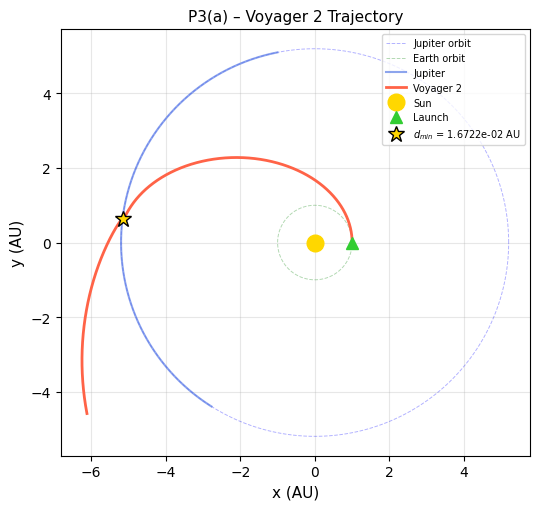

In [14]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(r_J*np.cos(theta_ring), r_J*np.sin(theta_ring), 'b--', lw=0.7, alpha=0.3, label="Jupiter orbit")
ax.plot(r_E*np.cos(theta_ring), r_E*np.sin(theta_ring), 'g--', lw=0.7, alpha=0.3, label="Earth orbit")
ax.plot(pos_J_p3[:,0], pos_J_p3[:,1], 'royalblue', lw=1.5, alpha=0.6, label='Jupiter')
ax.plot(pos_V_p3[:,0], pos_V_p3[:,1], 'tomato',    lw=2.0, label='Voyager 2')
ax.plot(0, 0, 'o', color='gold',       ms=12, zorder=6, label='Sun')
ax.plot(*pos_V_p3[0], '^', color='limegreen', ms=8, zorder=6, label='Launch')
ax.plot(*pos_V_p3[idx_min_p3], '*', color='gold', ms=12, zorder=7,
        markeredgecolor='black', markeredgewidth=1,
        label=r'$d_{min}$ = '+f'{dist_JV_p3[idx_min_p3]:.4e} AU')
ax.set_aspect('equal')
ax.set_xlabel('x (AU)', fontsize=11); ax.set_ylabel('y (AU)', fontsize=11)
ax.set_title('P3(a) – Voyager 2 Trajectory', fontsize=11)
ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('prob3a_trajectory.png', dpi=100, bbox_inches='tight'); plt.show()

In [15]:
# P3(a): Dual-panel animation — orbit trajectory (left) + live speed (right)
def make_p3a_animation(stride=50, fps=20):
    frames  = list(range(0, n_p3 + 1, stride))
    spd_V   = np.linalg.norm(vel_V_p3, axis=1) * VU          # km/s
    dist_V  = np.linalg.norm(pos_V_p3 - pos_J_p3, axis=1)
    idx_fly = int(np.argmin(dist_V))
    max_r   = max(np.linalg.norm(pos_V_p3, axis=1).max(),
                  np.linalg.norm(pos_J_p3, axis=1).max(), 6.5) * 1.12

    fig = plt.figure(figsize=(13, 5.5))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1.12, 1], figure=fig, wspace=0.28)
    ax_t = fig.add_subplot(gs[0])
    ax_s = fig.add_subplot(gs[1])
    fig.suptitle(
        r'P3(a): Voyager 2 Gravity Assist at Jupiter  |  '
        r'$\theta_{J,0}^{\rm nom}=97.15°$,  offset $+4°$  $\Rightarrow$  '
        r'$\theta_{J,0}=101.15°$',
        fontsize=10, fontweight='bold')

    def animate(fi):
        k = frames[fi]; ax_t.clear(); ax_s.clear()
        # ── orbit panel ──
        ax_t.plot(r_J*np.cos(theta_ring), r_J*np.sin(theta_ring),
                  'b--', lw=0.7, alpha=0.28)
        ax_t.plot(r_E*np.cos(theta_ring), r_E*np.sin(theta_ring),
                  'g--', lw=0.7, alpha=0.28)
        step = max(1, k // 600)
        ax_t.plot(pos_J_p3[:k+1:step, 0], pos_J_p3[:k+1:step, 1],
                  'royalblue', lw=1.8, alpha=0.50, label='Jupiter')
        ax_t.plot(pos_V_p3[:k+1:step, 0], pos_V_p3[:k+1:step, 1],
                  'crimson', lw=2.2, alpha=0.90, label='Voyager 2')
        ax_t.plot(*pos_J_p3[k], 'o', color='royalblue', ms=12, zorder=6)
        ax_t.plot(*pos_V_p3[k], 'o', color='crimson',   ms=8,  zorder=6)
        ax_t.plot(0, 0, 'o', color='gold', ms=16, zorder=7, label='Sun')
        ax_t.plot(*pos_V_p3[0], '^', color='limegreen', ms=9, zorder=7, label='Launch')
        if k >= idx_fly:
            ax_t.plot(*pos_V_p3[idx_fly], '*', color='white', ms=14, zorder=8,
                      markeredgecolor='black', markeredgewidth=1.2,
                      label=r'Flyby  $d$=' + f'{dist_V[idx_fly]:.3f} AU')
        ax_t.text(0.03, 0.97, f't = {t_p3[k]*12:.1f} mo',
                  transform=ax_t.transAxes, fontsize=12, va='top', fontweight='bold')
        ax_t.text(0.03, 0.90, f'v = {spd_V[k]:.1f} km/s',
                  transform=ax_t.transAxes, fontsize=12, va='top', color='crimson')
        ax_t.set_xlim(-max_r, max_r); ax_t.set_ylim(-max_r, max_r)
        ax_t.set_aspect('equal')
        ax_t.set_xlabel('x (AU)', fontsize=11); ax_t.set_ylabel('y (AU)', fontsize=11)
        ax_t.set_title('Trajectory', fontsize=11)
        ax_t.legend(fontsize=8, loc='upper right', ncol=2,
                    handlelength=1.2, handletextpad=0.4, columnspacing=0.8)
        ax_t.grid(alpha=0.25)
        # ── speed panel ──
        ax_s.plot(t_p3[:k+1] * 12, spd_V[:k+1], color='crimson', lw=2.2)
        ax_s.axvline(t_p3[idx_fly] * 12, color='gray', ls='--', lw=1.5, label='Flyby')
        if k > idx_fly:
            ib = max(0, idx_fly - 1500); ia = min(n_p3, idx_fly + 1500)
            v_bef = spd_V[ib]; v_aft = spd_V[ia]; dv = v_aft - v_bef
            ax_s.axhline(v_bef, color='steelblue',  ls=':', lw=1.5,
                         label=rf'$v_{{bef}}$={v_bef:.1f} km/s')
            ax_s.axhline(v_aft, color='darkorange', ls=':', lw=1.5,
                         label=rf'$v_{{aft}}$={v_aft:.1f} km/s')
            col_dv = 'green' if dv >= 0 else 'red'
            ax_s.text(0.97, 0.97, rf'$\Delta v$ = {dv:+.1f} km/s',
                      transform=ax_s.transAxes, fontsize=13,
                      ha='right', va='top', color=col_dv, fontweight='bold')
        ax_s.set_xlim(0, t_p3[-1] * 12)
        ax_s.set_ylim(0, spd_V.max() * 1.18)
        ax_s.set_xlabel('Time (months)', fontsize=11)
        ax_s.set_ylabel('Speed (km/s)', fontsize=11)
        ax_s.set_title('Voyager 2 Speed', fontsize=11)
        ax_s.legend(fontsize=9, loc='upper left')
        ax_s.grid(alpha=0.28)
        return []

    return animation.FuncAnimation(fig, animate, frames=len(frames),
                                   interval=40, blit=False)

print("Generating P3(a) dual-panel animation ...", flush=True)
anim_p3a = make_p3a_animation(stride=50)
_try_save(anim_p3a, 'Scenario P3a Voyager Jupiter.mp4')
plt.close('all')
print("✓ Animation saved to 'Scenario P3a Voyager Jupiter.mp4'")

Generating P3(a) dual-panel animation ...
  Saved → Scenario P3a Voyager Jupiter.gif  (install ffmpeg for MP4)
✓ Animation saved to 'Scenario P3a Voyager Jupiter.mp4'


### Part (b): Speed Profile and Gravity-Assist $\Delta v$

The speed rises sharply at closest approach as gravitational potential energy
converts to kinetic energy. After the flyby, Voyager settles at a **permanently
higher** heliocentric speed — Jupiter's orbital velocity has been asymmetrically
transferred to Voyager.

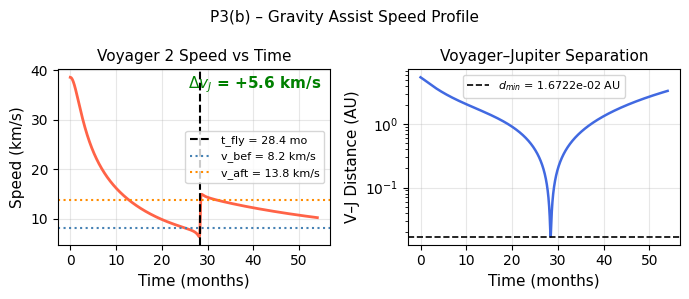

Speed before flyby : v_bef = 8.20 km/s
Speed after  flyby : v_aft = 13.77 km/s
Jupiter Δv         : +5.57 km/s


In [16]:
idx_bef = max(0,     idx_min_p3 - 1500)
idx_aft = min(n_p3,  idx_min_p3 + 1500)
v_bef   = spd_V_p3[idx_bef]; v_aft = spd_V_p3[idx_aft]; dv_J = v_aft - v_bef

fig, axes = plt.subplots(1, 2, figsize=(7, 3.0))

axes[0].plot(t_p3*12, spd_V_p3, 'tomato', lw=2.0)
axes[0].axvline(t_p3[idx_min_p3]*12, color='k', ls='--', lw=1.5,
                label=f't_fly = {t_p3[idx_min_p3]*12:.1f} mo')
axes[0].axhline(v_bef, color='steelblue',  ls=':', lw=1.5, label=f'v_bef = {v_bef:.1f} km/s')
axes[0].axhline(v_aft, color='darkorange', ls=':', lw=1.5, label=f'v_aft = {v_aft:.1f} km/s')
col_dv = 'green' if dv_J >= 0 else 'red'
axes[0].text(0.97, 0.97, r'$\Delta v_J$ = '+f'{dv_J:+.1f} km/s',
             transform=axes[0].transAxes, fontsize=11, ha='right', va='top',
             color=col_dv, fontweight='bold')
axes[0].set_xlabel('Time (months)', fontsize=11); axes[0].set_ylabel('Speed (km/s)', fontsize=11)
axes[0].set_title('Voyager 2 Speed vs Time', fontsize=11)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(t_p3*12, dist_JV_p3, 'royalblue', lw=1.8)
axes[1].axhline(dist_JV_p3[idx_min_p3], color='k', ls='--', lw=1.2,
                label=r'$d_{min}$ = '+f'{dist_JV_p3[idx_min_p3]:.4e} AU')
axes[1].set_yscale('log')
axes[1].set_xlabel('Time (months)', fontsize=11); axes[1].set_ylabel('V–J Distance (AU)', fontsize=11)
axes[1].set_title('Voyager–Jupiter Separation', fontsize=11)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.suptitle('P3(b) – Gravity Assist Speed Profile', fontsize=11)
plt.tight_layout()
plt.savefig('prob3b_speed.png', dpi=100, bbox_inches='tight'); plt.show()

print(f"Speed before flyby : v_bef = {v_bef:.2f} km/s")
print(f"Speed after  flyby : v_aft = {v_aft:.2f} km/s")
print(f"Jupiter Δv         : {dv_J:+.2f} km/s")

---
## Bonus: Three Gravity-Assist Scenarios (A, C)

| Scenario | Jupiter θ₀ | Launch speed | Flyby type |
|---|---|---|---|
| **A** – Close Prograde    | 100.2° | $v_H$ | Prograde, close approach → large $\Delta v$ |
| **C** – Retrograde        | 94.3° | $v_{esc}$ | Retrograde flyby → *speed loss* |

Each scenario uses the same leapfrog integrator for 10 yr (50,000 steps).

In [17]:
bonus_cfgs = [
    dict(label='A', name='Close Prograde',    v=v_H,   theta=100.2,  color='crimson'),
    dict(label='C', name='Retrograde',        v=v_esc, theta=94.3,   color='tomato'),
]

bonus_results = []
for cfg in bonus_cfgs:
    th   = np.radians(cfg['theta'])
    pJ0b = np.array([r_J*np.cos(th),  r_J*np.sin(th)])
    vJ0b = np.array([-v_J*np.sin(th), v_J*np.cos(th)])
    pV0b = np.array([r_E, 0.0]); vV0b = np.array([0.0, cfg['v']])
    n_b  = int(6.0/0.0002); t_b = np.arange(n_b+1)*0.0002   # 6 yr covers all flybys
    t0   = time.perf_counter()
    pJb, _, pVb, vVb = sim_leapfrog_jv(pJ0b,vJ0b,pV0b,vV0b,0.0002,n_b,G,M_sun,M_jup)
    elapsed = time.perf_counter()-t0
    spdb  = np.linalg.norm(vVb, axis=1)*VU
    distb = np.linalg.norm(pVb-pJb, axis=1)
    idx   = np.argmin(distb)
    ib=max(0,idx-500); ia=min(n_b,idx+500)
    dv = spdb[ia]-spdb[ib]
    bonus_results.append({**cfg,'t':t_b,'pJ':pJb,'pV':pVb,'spd':spdb,'dist':distb,
                          'idx_min':idx,'v_before':spdb[ib],'v_after':spdb[ia],'dv':dv})
    print(f"Scenario {cfg['label']} ({cfg['name']:20s}): {elapsed:.2f} s  |  "
          f"d_min = {distb[idx]:.4e} AU  |  dv = {dv:+.1f} km/s")

Scenario A (Close Prograde      ): 0.06 s  |  d_min = 3.5155e-03 AU  |  dv = +11.1 km/s
Scenario C (Retrograde          ): 0.06 s  |  d_min = 3.8431e-03 AU  |  dv = -12.3 km/s


### Bonus: Trajectory and Speed Plots

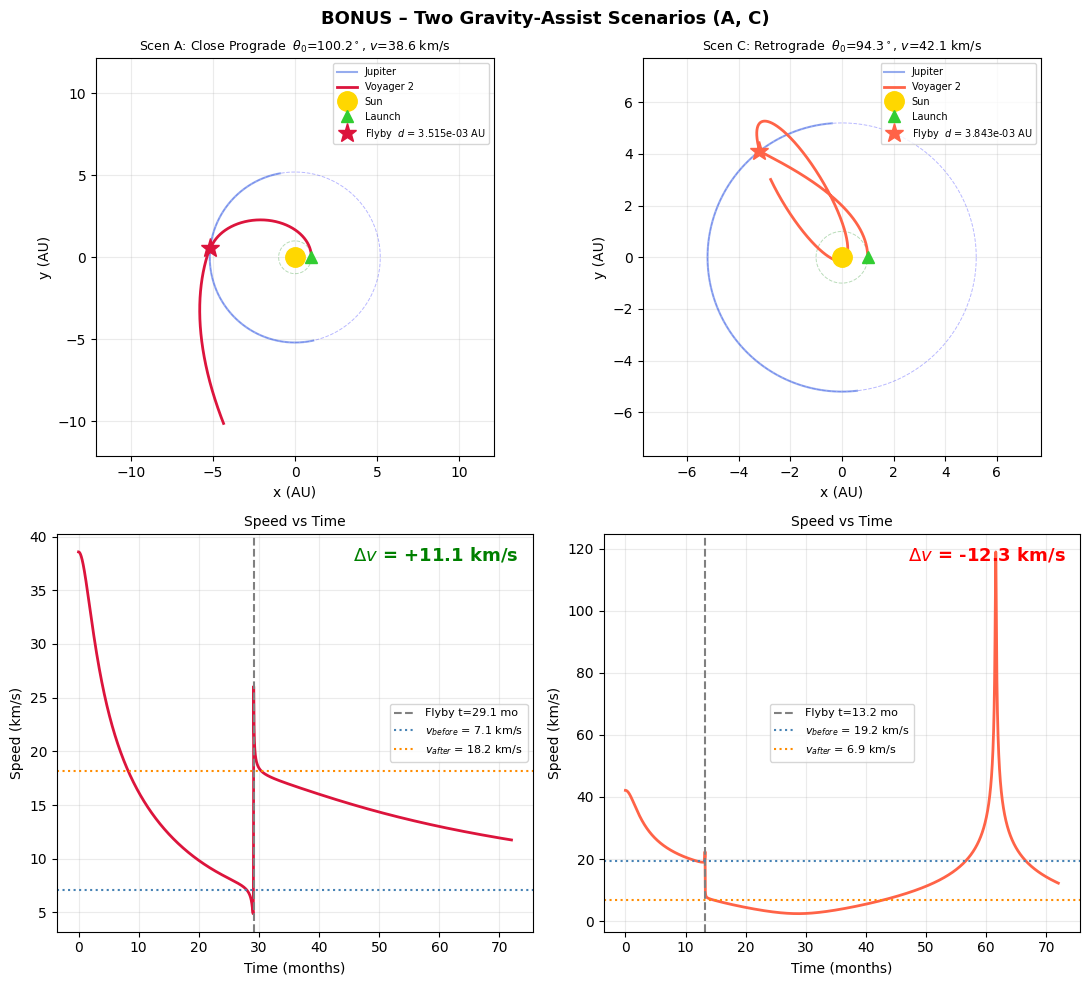

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for col, s in enumerate(bonus_results):
    idx = s['idx_min']
    ax = axes[0, col]
    ax.plot(r_J*np.cos(theta_ring), r_J*np.sin(theta_ring), 'b--', lw=0.7, alpha=0.28)
    ax.plot(r_E*np.cos(theta_ring), r_E*np.sin(theta_ring), 'g--', lw=0.7, alpha=0.28)
    ax.plot(s['pJ'][:,0], s['pJ'][:,1], 'royalblue', lw=1.5, alpha=0.55, label='Jupiter')
    ax.plot(s['pV'][:,0], s['pV'][:,1], color=s['color'], lw=2.0, label='Voyager 2')
    ax.plot(0, 0, 'o', color='gold', ms=14, zorder=6, label='Sun')
    ax.plot(*s['pV'][0], '^', color='limegreen', ms=8, zorder=6, label='Launch')
    ax.plot(*s['pV'][idx], '*', color=s['color'], ms=14, zorder=7,
            label=r'Flyby  $d$ = '+f"{s['dist'][idx]:.3e} AU")
    lim = max(np.linalg.norm(s['pV'], axis=1).max(), 7.0)*1.1
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect('equal')
    ax.set_xlabel('x (AU)', fontsize=10); ax.set_ylabel('y (AU)', fontsize=10)
    ax.set_title(f"Scen {s['label']}: {s['name']}  "
                 r"$\theta_0$="+f"{s['theta']}"+r"$^\circ$, "
                 r"$v$="+f"{s['v']*VU:.1f} km/s", fontsize=9)
    ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=0.25)

    ax2 = axes[1, col]
    ax2.plot(s['t']*12, s['spd'], color=s['color'], lw=2.0)
    ax2.axvline(s['t'][idx]*12, color='gray', ls='--', lw=1.5,
                label=f"Flyby t={s['t'][idx]*12:.1f} mo")
    ax2.axhline(s['v_before'], color='steelblue',  ls=':', lw=1.5,
                label=r'$v_{before}$ = '+f"{s['v_before']:.1f} km/s")
    ax2.axhline(s['v_after'],  color='darkorange', ls=':', lw=1.5,
                label=r'$v_{after}$ = '+f"{s['v_after']:.1f} km/s")
    col_dv = 'green' if s['dv'] >= 0 else 'red'
    ax2.text(0.97, 0.97, r'$\Delta v$ = '+f"{s['dv']:+.1f} km/s",
             transform=ax2.transAxes, fontsize=13, ha='right', va='top',
             color=col_dv, fontweight='bold')
    ax2.set_xlabel('Time (months)', fontsize=10); ax2.set_ylabel('Speed (km/s)', fontsize=10)
    ax2.set_title('Speed vs Time', fontsize=10)
    ax2.legend(fontsize=8); ax2.grid(alpha=0.25)

plt.suptitle('BONUS – Two Gravity-Assist Scenarios (A, C)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bonus_scenarios.png', dpi=100, bbox_inches='tight'); plt.show()

### Bonus Animations (Scenarios A, C)

Each panel shows the trajectory (left) and live speed readout (right).

In [19]:
def make_ga_animation(s, stride=80, fps=20):
    t,pJ,pV   = s['t'],s['pJ'],s['pV']
    spd,dist  = s['spd'],s['dist']
    idx_fly   = s['idx_min']
    frames    = list(range(0, len(t), stride))
    max_r     = max(np.linalg.norm(pV,axis=1).max(), np.linalg.norm(pJ,axis=1).max(), 6.5)*1.12
    fig = plt.figure(figsize=(13, 5.5))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1.12,1], figure=fig, wspace=0.28)
    ax_t = fig.add_subplot(gs[0]); ax_s = fig.add_subplot(gs[1])
    fig.suptitle(f"Scenario {s['label']}: {s['name']}  |  "
                 r"$\theta_0$="+f"{s['theta']}"+r"$^\circ$  |  "
                 r"$v$="+f"{s['v']*VU:.1f} km/s", fontsize=11, fontweight='bold')
    def animate(fi):
        k = frames[fi]; ax_t.clear(); ax_s.clear()
        ax_t.plot(r_J*np.cos(theta_ring),r_J*np.sin(theta_ring),'b--',lw=0.7,alpha=0.28)
        ax_t.plot(r_E*np.cos(theta_ring),r_E*np.sin(theta_ring),'g--',lw=0.7,alpha=0.28)
        step = max(1, k//600)
        ax_t.plot(pJ[:k+1:step,0],pJ[:k+1:step,1],'royalblue',lw=1.8,alpha=0.50)
        ax_t.plot(pV[:k+1:step,0],pV[:k+1:step,1],color=s['color'],lw=2.2,alpha=0.90)
        ax_t.plot(*pJ[k],'o',color='royalblue',ms=12,zorder=6,label='Jupiter')
        ax_t.plot(*pV[k],'o',color=s['color'],ms=8,zorder=6,label='Voyager 2')
        ax_t.plot(0,0,'o',color='gold',ms=16,zorder=7,label='Sun')
        ax_t.plot(*pV[0],'^',color='limegreen',ms=9,zorder=7,label='Launch')
        if k >= idx_fly:
            ax_t.plot(*pV[idx_fly],'*',color='white',ms=14,zorder=8,
                      markeredgecolor='black',markeredgewidth=1.2,
                      label=r'Flyby  $d$='+f"{dist[idx_fly]:.3f} AU")
        ax_t.text(0.03,0.97,f"t={t[k]*12:.1f} mo",transform=ax_t.transAxes,
                  fontsize=12,va='top',fontweight='bold')
        ax_t.text(0.03,0.90,f"v={spd[k]:.1f} km/s",transform=ax_t.transAxes,
                  fontsize=12,va='top',color=s['color'])
        ax_t.set_xlim(-max_r,max_r); ax_t.set_ylim(-max_r,max_r); ax_t.set_aspect('equal')
        ax_t.set_xlabel('x (AU)',fontsize=11); ax_t.set_ylabel('y (AU)',fontsize=11)
        ax_t.legend(fontsize=8,loc='upper right',ncol=2,
                    handlelength=1.2,handletextpad=0.4,columnspacing=0.8)
        ax_t.grid(alpha=0.25)
        ax_s.plot(t[:k+1]*12,spd[:k+1],color=s['color'],lw=2.2)
        ax_s.axvline(t[idx_fly]*12,color='gray',ls='--',lw=1.5)
        if k > idx_fly:
            ax_s.axhline(s['v_before'],color='steelblue', ls=':',lw=1.5,
                         label=r'$v_{bef}$='+f"{s['v_before']:.1f}")
            ax_s.axhline(s['v_after'], color='darkorange',ls=':',lw=1.5,
                         label=r'$v_{aft}$='+f"{s['v_after']:.1f}")
            col_dv = 'green' if s['dv'] >= 0 else 'red'
            ax_s.text(0.97,0.97,r'$\Delta v$='+f"{s['dv']:+.1f} km/s",
                      transform=ax_s.transAxes,fontsize=13,ha='right',va='top',
                      color=col_dv,fontweight='bold')
        ax_s.set_xlim(0,t[-1]*12); ax_s.set_ylim(0, max(spd)*1.18)
        ax_s.set_xlabel('Time (months)',fontsize=11); ax_s.set_ylabel('Speed (km/s)',fontsize=11)
        ax_s.set_title(f"Scenario {s['label']} Speed",fontsize=11); ax_s.grid(alpha=0.28)
        return []
    return animation.FuncAnimation(fig, animate, frames=len(frames), interval=40, blit=False)

print("Generating Scenario A animation ...", flush=True)
anim_A = make_ga_animation(bonus_results[0], stride=100)
_try_save(anim_A, 'Scenario A Close Prograde.mp4')
plt.close('all')
print("✓ Animation saved to 'Scenario A Close Prograde.mp4'")

Generating Scenario A animation ...
  Saved → Scenario A Close Prograde.gif  (install ffmpeg for MP4)
✓ Animation saved to 'Scenario A Close Prograde.mp4'


In [20]:
print('Generating Scenario C animation ...', flush=True)
anim_C = make_ga_animation(bonus_results[1], stride=120)
_try_save(anim_C, 'Scenario C Retrograde.mp4')
plt.close('all')
print("✓ Animation saved to 'Scenario C Retrograde.mp4'")

Generating Scenario C animation ...
  Saved → Scenario C Retrograde.gif  (install ffmpeg for MP4)
✓ Animation saved to 'Scenario C Retrograde.mp4'


---
## Summary

| Problem | Δt (yr) | Steps | Integrators |
|---|---|---|---|
| P1(a–c): circular orbit, 3 periods | 0.002 | 1,500 | Leapfrog + Euler |
| P2(a–b): elliptical orbit, 5 periods | 0.002 | ~1,576 | Leapfrog + Euler |
| P3(a–b): Voyager + Jupiter, 4.5 yr | 0.0002 | 22,500 | Leapfrog |
| [Bonus] Each scenario, 6 yr | 0.0002 | 30,000 | Leapfrog |